# Importing required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Importing the dataset

In [ ]:
df = pd.read_csv('../data/cardio_train.csv', sep=';')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0
6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0
7,12,22584,2,178,95.0,130,90,3,3,0,0,1,1
8,13,17668,1,158,71.0,110,70,1,1,0,0,1,0
9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0


# Inspection

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [7]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
print(df.duplicated().sum())

0


In [18]:
cat_cols = ['gender','cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
for col in cat_cols:
    print(f"{df[col].value_counts()}\n")

gender
1    45530
2    24470
Name: count, dtype: int64

cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

gluc
1    59479
3     5331
2     5190
Name: count, dtype: int64

smoke
0    63831
1     6169
Name: count, dtype: int64

alco
0    66236
1     3764
Name: count, dtype: int64

active
1    56261
0    13739
Name: count, dtype: int64

cardio
0    35021
1    34979
Name: count, dtype: int64



In [20]:
for col in ['height', 'weight', 'ap_hi', 'ap_lo']:
    print(f"\n{col}")
    print("Lowest:", sorted(df[col].unique())[:10])
    print("Highest:", sorted(df[col].unique())[-10:])


height
Lowest: [np.int64(55), np.int64(57), np.int64(59), np.int64(60), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(70)]
Highest: [np.int64(192), np.int64(193), np.int64(194), np.int64(195), np.int64(196), np.int64(197), np.int64(198), np.int64(200), np.int64(207), np.int64(250)]

weight
Lowest: [np.float64(10.0), np.float64(11.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(32.0)]
Highest: [np.float64(170.0), np.float64(171.0), np.float64(172.0), np.float64(175.0), np.float64(177.0), np.float64(178.0), np.float64(180.0), np.float64(181.0), np.float64(183.0), np.float64(200.0)]

ap_hi
Lowest: [np.int64(-150), np.int64(-140), np.int64(-120), np.int64(-115), np.int64(-100), np.int64(1), np.int64(7), np.int64(10), np.int64(11), np.int64(12)]
Highest: [np.int64(1409), np.int64(1420), np.int64(1500), np.int64(1620), np.int64(2000), np.int64(11020), np.int64(11500)

In [29]:
print("Height < 100:", (df['height'] < 100).sum())
print("Height > 220:", (df['height'] > 220).sum())

print("Weight < 30:", (df['weight'] < 30).sum())
print("Weight > 200:", (df['weight'] > 200).sum())

print("Systolic BP <= 0:", (df['ap_hi'] <= 0).sum())
print("Systolic BP > 250:", (df['ap_hi'] > 250).sum())

print("Diastolic BP <= 0:", (df['ap_lo'] <= 0).sum())
print("Diastolic BP > 250:", (df['ap_lo'] > 250).sum())

Height < 100: 29
Height > 220: 1
Weight < 30: 7
Weight > 200: 0
Systolic BP <= 0: 7
Systolic BP > 250: 40
Diastolic BP <= 0: 22
Diastolic BP > 250: 953


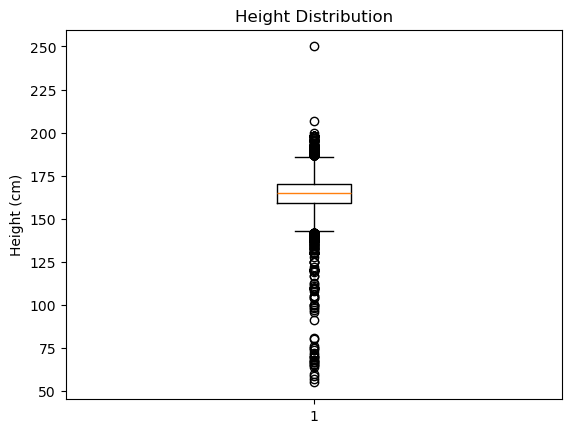

In [31]:
# height

plt.boxplot(df['height'])
plt.title('Height Distribution')
plt.ylabel('Height (cm)')
plt.show()

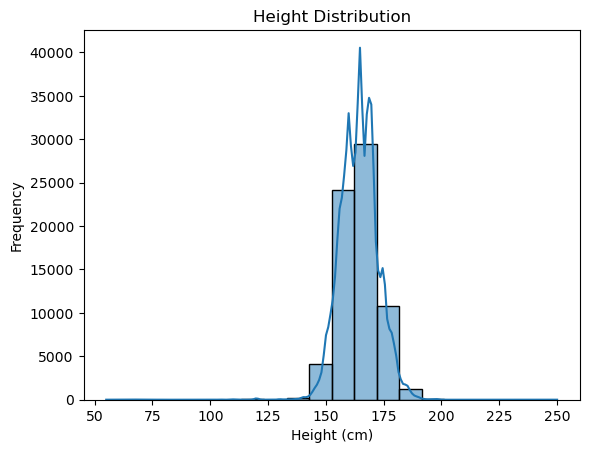

In [39]:
sns.histplot(df['height'], bins=20, kde=True, edgecolor='black')

plt.title('Height Distribution')
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')

plt.show()

In [ ]:
Q1 = df['height'].quantile(0.25)
Q3 = df['height'].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)

Q1: 159.0
Q3: 170.0
IQR: 11.0
Lower fence: 142.5
Upper fence: 186.5


In [36]:
df[(df['height'] < 100) | (df['height'] > 220)]

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
224,309,21800,2,76,55.0,120,80,1,1,0,0,1,0
6486,9223,21220,1,250,86.0,140,100,3,1,0,0,1,1
7598,10843,14661,2,70,72.0,120,8,1,1,0,0,1,0
8171,11662,17646,2,97,170.0,160,100,1,1,1,0,1,1
12770,18218,19594,1,75,168.0,120,80,1,1,1,0,1,1
13265,18928,22456,2,71,68.0,120,80,3,1,0,0,1,0
14323,20459,22005,1,67,57.0,120,90,1,1,0,0,1,1
15167,21686,15812,1,70,68.0,120,80,1,1,0,0,0,0
16699,23859,19680,2,74,98.0,140,90,1,1,0,0,1,1
17277,24690,17530,1,98,45.0,12,80,1,1,0,0,1,0


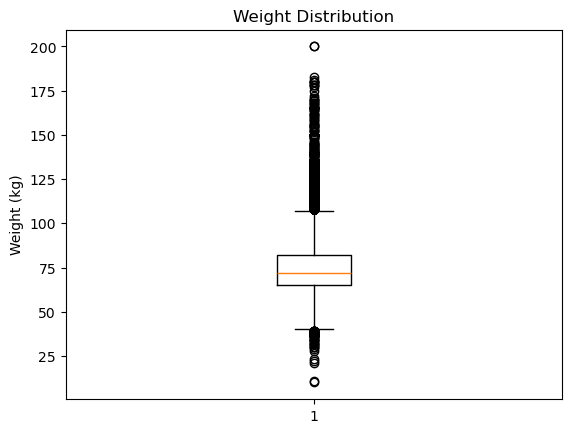

In [37]:
# Weight

plt.boxplot(df['weight'])
plt.title('Weight Distribution')
plt.ylabel('Weight (kg)')
plt.show()

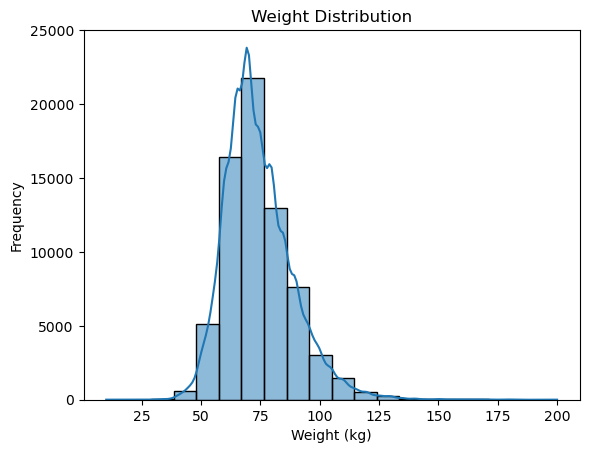

In [40]:
sns.histplot(df['weight'], bins=20, kde=True, edgecolor='black')

plt.title('Weight Distribution')
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency')

plt.show()

In [41]:
Q1 = df['weight'].quantile(0.25)
Q3 = df['weight'].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)

Q1: 65.0
Q3: 82.0
IQR: 17.0
Lower fence: 39.5
Upper fence: 107.5


In [43]:
df[(df['weight'] < 30) | (df['weight'] > 200)]

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
26806,38312,23284,1,157,23.0,110,80,1,1,0,0,1,0
29488,42156,20408,2,177,22.0,120,80,1,1,1,1,1,0
33817,48318,21582,2,178,11.0,130,90,1,1,0,0,1,1
34276,48976,14664,2,128,28.0,120,80,1,1,0,0,1,0
57858,82567,18804,2,165,10.0,180,1100,2,2,0,0,1,1
60188,85931,21855,1,162,21.0,120,80,2,1,0,0,1,1
60699,86650,18875,1,171,29.0,110,70,2,1,0,0,1,1


In [ ]:
# ap_hi



ap_hi
-150      1
-140      1
-120      2
-115      1
-100      2
         ..
 11020    1
 11500    1
 13010    2
 14020    4
 16020    1
Name: count, Length: 153, dtype: int64

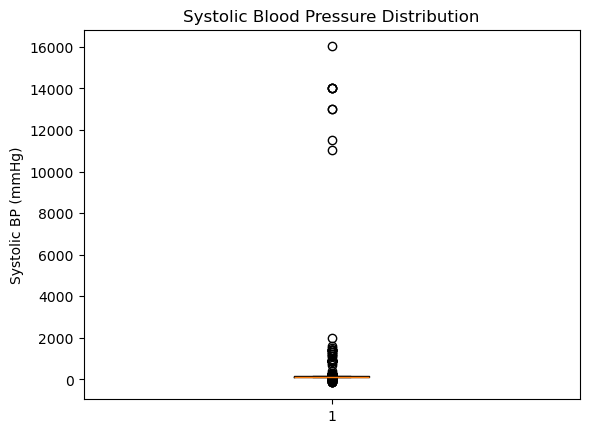

In [45]:
plt.boxplot(df['ap_hi'])
plt.title('Systolic Blood Pressure Distribution')
plt.ylabel('Systolic BP (mmHg)')
plt.show()

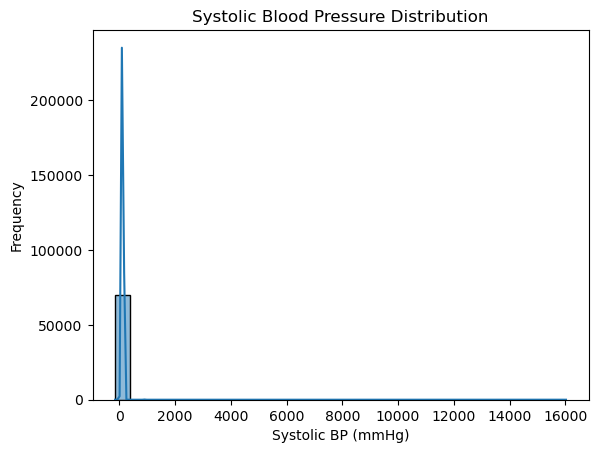

In [46]:
sns.histplot(df['ap_hi'], bins=30, kde=True, edgecolor='black')

plt.title('Systolic Blood Pressure Distribution')
plt.xlabel('Systolic BP (mmHg)')
plt.ylabel('Frequency')

plt.show()

In [47]:
Q1 = df['ap_hi'].quantile(0.25)
Q3 = df['ap_hi'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)

Q1: 120.0
Q3: 140.0
IQR: 20.0
Lower fence: 90.0
Upper fence: 170.0


In [48]:
df[(df['ap_hi'] <= 0) | (df['ap_hi'] > 250)]

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
1876,2654,15116,1,160,60.0,902,60,1,1,0,0,1,0
2014,2845,22712,2,167,59.0,906,0,1,1,0,0,1,0
4607,6525,15281,1,165,78.0,-100,80,2,1,0,0,1,0
4817,6822,14425,1,168,63.0,909,60,2,1,0,0,1,0
7763,11089,21032,1,175,80.0,11500,90,1,1,0,0,1,1
8915,12710,18870,1,164,75.0,1420,80,2,1,0,0,1,1
9557,13616,22659,1,155,87.0,701,110,1,1,0,0,1,1
13895,19827,15996,1,168,72.0,1500,80,1,1,0,0,1,1
16021,22881,22108,2,161,90.0,-115,70,1,1,0,0,1,0
17713,25314,22398,2,163,50.0,907,70,3,3,0,0,1,1


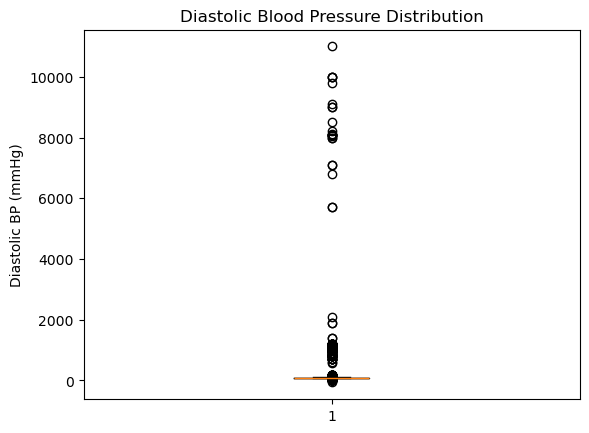

In [50]:
# ap_lo

plt.boxplot(df['ap_lo'])
plt.title('Diastolic Blood Pressure Distribution')
plt.ylabel('Diastolic BP (mmHg)')
plt.show()

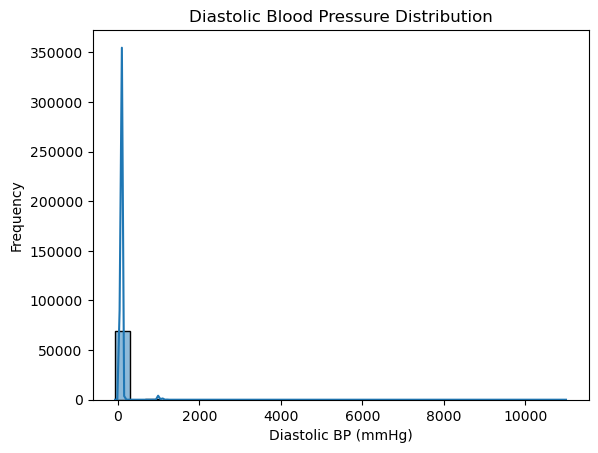

In [51]:
sns.histplot(df['ap_lo'], bins=30, kde=True, edgecolor='black')

plt.title('Diastolic Blood Pressure Distribution')
plt.xlabel('Diastolic BP (mmHg)')
plt.ylabel('Frequency')

plt.show()

In [52]:
Q1 = df['ap_lo'].quantile(0.25)
Q3 = df['ap_lo'].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Fence:", Q1 - 1.5 * IQR)
print("Upper Fence:", Q3 + 1.5 * IQR)

Q1: 80.0
Q3: 90.0
IQR: 10.0
Lower Fence: 65.0
Upper Fence: 105.0


In [61]:
df[(df['ap_lo'] < 0) | (df['ap_lo'] >= 250)].head(30)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
228,314,17489,2,183,98.0,160,1100,1,2,1,0,1,1
241,334,21932,2,157,60.0,160,1000,2,1,0,0,0,1
260,357,18217,1,150,83.0,140,800,1,1,0,0,1,1
329,458,23407,1,176,63.0,160,1000,2,2,0,0,0,1
345,482,18704,1,154,81.0,140,1000,2,1,0,0,1,1
473,680,15226,1,150,95.0,150,1033,1,1,0,0,1,1
559,805,20430,2,173,101.0,200,1000,1,1,0,0,1,1
613,886,18963,1,165,92.0,140,1000,1,1,1,0,1,1
649,928,18190,1,166,57.0,190,1100,1,1,0,0,1,1
653,932,21842,1,156,72.0,180,1000,2,1,0,0,0,1


In [63]:
print((df['ap_hi'] <= df['ap_lo']).sum())

1236


In [65]:
df[df['ap_hi'] <= df['ap_lo']][['ap_hi', 'ap_lo']].head(30)

,ap_hi,ap_lo
228,160,1100
241,160,1000
260,140,800
329,160,1000
345,140,1000
473,150,1033
474,120,150
559,200,1000
567,14,90
613,140,1000


#Cleaning

In [116]:
# copying df to a new dataframe for cleaning and preprocessing
clean_df = df.copy()
clean_df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [117]:
clean_df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [118]:
# renaming columns for better understanding

clean_df.rename(columns={
    'ap_hi': 'systolic_bp',
    'ap_lo': 'diastolic_bp',
    'cholesterol': 'cholesterol_level',
    'gluc': 'glucose_level',
    'smoke': 'smoking',
    'alco': 'alcohol',
    'active': 'physical_activity',
    'cardio': 'cardiovascular_disease'
}, inplace=True)

In [119]:
clean_df['age'] = (clean_df['age'] / 365.25).round().astype(int)
clean_df

,id,age,gender,height,weight,systolic_bp,diastolic_bp,cholesterol_level,glucose_level,smoking,alcohol,physical_activity,cardiovascular_disease
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,52,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,48,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,53,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,62,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1


In [120]:
# removing outliers based on realistic domain knowledge and statistical analysis

clean_df = clean_df[(clean_df['height'] >= 100) & (clean_df['height'] <= 220)]
clean_df = clean_df[clean_df['weight'] >= 30]
clean_df = clean_df[(clean_df['systolic_bp'] > 0) & (clean_df['systolic_bp'] <= 250)]
clean_df = clean_df[(clean_df['diastolic_bp'] > 0) & (clean_df['diastolic_bp'] < 250)]


In [121]:
clean_df

,id,age,gender,height,weight,systolic_bp,diastolic_bp,cholesterol_level,glucose_level,smoking,alcohol,physical_activity,cardiovascular_disease
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,52,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,48,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,53,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,62,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1


In [123]:
print((clean_df['systolic_bp'] <= clean_df['diastolic_bp']).sum())

274


In [125]:
clean_df = clean_df[clean_df['systolic_bp'] > clean_df['diastolic_bp']]
clean_df

,id,age,gender,height,weight,systolic_bp,diastolic_bp,cholesterol_level,glucose_level,smoking,alcohol,physical_activity,cardiovascular_disease
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,52,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,48,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,53,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,62,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1


# Preprocessing

## 1. Feature Selection